# The same experiment through `transcribe()` instead of `decode()`

`Aug_23.ipynb` measured how utterance position inside Whisper's 30 s window affects corpus WER,
using `whisper.decode()` - one encoder pass and one greedy decode per window, deliberately
stripped of everything `transcribe()` layers on top. This notebook re-runs that experiment on the
**same 1000 clips** through `model.transcribe()`, to measure what those extra layers actually do.

Two fallback arms are run, because the choice turns out to matter more than it looks:

| arm | `temperature` | what it means |
|---|---|---|
| `greedy` | `0.0` (scalar) | honours the original control list literally. The fallback ladder never fires, so `compression_ratio_threshold` and `logprob_threshold` are **inert**. |
| `stock` | `(0.0, 0.2, 0.4, 0.6, 0.8, 1.0)` | Whisper as shipped. A repetitive or low-confidence window is re-decoded at rising temperature. |

1000 clips x 6 offsets x 2 timestamp modes x 2 fallback arms = **24 000 `transcribe()` calls**.
Unlike `decode()`, `transcribe()` takes audio rather than a mel and cannot be batched, so this is
sequential.

## 1. Imports and the control register

Everything is held identical to `Aug_23.ipynb` except the decode path and the fallback arm, so any
difference in the resulting curves is attributable to `transcribe()` rather than to a changed
control.

Two mappings need care:

- **`initial_prompt=""` is not "no prompt".** `transcribe()` computes
  `tokenizer.encode(" " + initial_prompt.strip())`, which for `""` yields `[220]` - a literal
  space token, prefixed with `<|startofprev|>`. That is a one-token prompt, not an absent one. To
  match the `decode()` run (`prompt=None`) this notebook passes `initial_prompt=None`.
- **`temperature` must be a scalar to stay greedy.** Passing the default tuple silently enables
  sampling on any window that trips a threshold.

The `stock` arm samples at temperature > 0 and is therefore stochastic. Each grid cell is seeded
from a hash of its own `(path, offset, timestamps, arm)` key, so the arm is reproducible and a
resumed run produces the same values as an uninterrupted one.

In [1]:
import collections, csv, hashlib, json, os, time

import numpy as np
import torch
import soundfile as sf
import whisper
from whisper.audio import N_SAMPLES, SAMPLE_RATE, HOP_LENGTH
from whisper.normalizers import EnglishTextNormalizer
from jiwer import process_words

CORPUS_DIR   = "corpus_frozen"
RESULTS_CSV  = "transcribe_results.csv"
DECODE_CSV   = "offset_results.csv"          # the decode() baseline, for comparison

OFFSETS_S    = [0, 5, 10, 15, 20, 25]
OFFSETS      = [s * SAMPLE_RATE for s in OFFSETS_S]
TS_ARMS      = [True, False]                 # timestamps on / off
FB_ARMS      = {
    "greedy": 0.0,                                     # scalar -> no fallback ladder
    "stock":  (0.0, 0.2, 0.4, 0.6, 0.8, 1.0),          # Whisper's shipped default
}

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

CONTROLS = {
    "model":                       "base",
    "device":                      DEVICE,
    "fp16":                        False,
    "task":                        "transcribe",
    "language":                    "en",
    "condition_on_previous_text":  False,
    "initial_prompt":              None,      # NOT "" -- see markdown above
    "carry_initial_prompt":        False,
    "word_timestamps":             False,
    "compression_ratio_threshold": 2.4,       # stock; only reachable in the `stock` arm
    "logprob_threshold":           -1.0,      # stock; only reachable in the `stock` arm
    "no_speech_threshold":         0.6,       # stock; ACTIVE in both arms
    "padding":                     "zeros only (np.zeros(480000, float32))",
    "offsets_s":                   OFFSETS_S,
    "fallback_arms":               {k: v for k, v in FB_ARMS.items()},
    "normalizer":                  "whisper EnglishTextNormalizer (both ref and hyp)",
    "wer":                         "corpus-level: pooled S+D+I over pooled reference length",
}

for s, n in zip(OFFSETS_S, OFFSETS):
    assert n % HOP_LENGTH == 0, f"offset {s}s is not a multiple of {HOP_LENGTH}"

print(f"whisper {whisper.__version__} | torch {torch.__version__}")
for k, v in CONTROLS.items():
    print(f"  {k:28s} {v}")

whisper 20250625 | torch 2.13.0
  model                        base
  device                       mps
  fp16                         False
  task                         transcribe
  language                     en
  condition_on_previous_text   False
  initial_prompt               None
  carry_initial_prompt         False
  word_timestamps              False
  compression_ratio_threshold  2.4
  logprob_threshold            -1.0
  no_speech_threshold          0.6
  padding                      zeros only (np.zeros(480000, float32))
  offsets_s                    [0, 5, 10, 15, 20, 25]
  fallback_arms                {'greedy': 0.0, 'stock': (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)}
  normalizer                   whisper EnglishTextNormalizer (both ref and hyp)
  wer                          corpus-level: pooled S+D+I over pooled reference length


## 2. The frozen corpus

Loaded through `load_frozen()` from `corpus_frozen/`, exactly as section 9 of `Aug_23.ipynb`
intended: no dependency on the TIMIT install, no path fixups, and every clip re-checked against
its frozen `sha256_audio` so a truncated or altered file fails at load rather than as a silent WER
delta.

The manifest also pins `results_csv_sha256`. Asserting it against the local `offset_results.csv`
proves the `decode()` baseline plotted later is the *same* results file the corpus was frozen
against - which is what makes the two experiments comparable by construction rather than by
assumption.

In [2]:
def sha256_file(path, buf=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(buf), b""):
            h.update(chunk)
    return h.hexdigest()


def sha256_audio(a):
    '''Digest of the decoded float32 samples - the array that actually reaches the mel.'''
    return hashlib.sha256(np.ascontiguousarray(a, dtype=np.float32).tobytes()).hexdigest()


def load_frozen(corpus_dir=CORPUS_DIR, verify=True):
    '''Corpus + audio with no dependency on the TIMIT install (see Aug_23.ipynb section 9).'''
    man = json.load(open(os.path.join(corpus_dir, "corpus_manifest.json")))
    audio = {}
    for r in man["files"]:
        a, sr = sf.read(os.path.join(corpus_dir, "audio", r["path"]), dtype="float32")
        if verify:
            assert sr == man["sample_rate"], (r["path"], sr)
            assert len(a) == r["samples"], (r["path"], len(a), r["samples"])
            assert sha256_audio(a) == r["sha256_audio"], f"{r['path']}: fails frozen digest"
        audio[r["path"]] = a
    return man, audio


t0 = time.time()
MAN, AUDIO = load_frozen()
FILES = MAN["files"]
print(f"loaded + verified {len(FILES)} clips in {time.time()-t0:.1f}s")
print(f"  frozen {MAN['created']} | whisper {MAN['whisper']} | torch {MAN['torch']}")

assert MAN["results_csv_sha256"] == sha256_file(DECODE_CSV), (
    "offset_results.csv differs from the file corpus_frozen/ was frozen against - "
    "the decode() baseline is not comparable to this corpus"
)
print(f"  decode() baseline {DECODE_CSV} matches the frozen digest "
      f"({MAN['results_csv_sha256'][:16]}...) -- comparable")

_d = [r["sec"] for r in FILES]
print(f"  {len(FILES)} files | {len({r['speaker'] for r in FILES})} speakers | "
      f"{sum(len(r['reference'].split()) for r in FILES)} reference words")
print(f"  duration min {min(_d):.3f}s  mean {sum(_d)/len(_d):.3f}s  max {max(_d):.3f}s")

loaded + verified 1000 clips in 0.5s
  frozen 2026-08-23 15:21:28 | whisper 20250625 | torch 2.13.0
  decode() baseline offset_results.csv matches the frozen digest (3a5c3fb0a8798ca1...) -- comparable
  1000 files | 168 speakers | 7918 reference words
  duration min 1.094s  mean 2.958s  max 4.973s


## 3. Placing the utterance

Identical to `Aug_23.ipynb`: an exact 480000-sample zero buffer with the utterance written in at
the offset. `transcribe()` takes this array directly rather than a precomputed mel.

Note what `transcribe()` then does internally: `log_mel_spectrogram(audio, padding=N_SAMPLES)`
appends a *further* 30 s of silence for slicing, giving a 6000-frame mel of which the first 3000
are content. So the mel the encoder sees for window 0 is the same one `decode()` was handed - the
extra padding only exists to let the seek loop read past the end safely.

In [3]:
def place(audio, off_samples):
    '''Utterance written into an all-zero 30 s buffer at `off_samples`. Zero padding only.'''
    buf = np.zeros(N_SAMPLES, dtype=np.float32)
    buf[off_samples:off_samples + len(audio)] = audio
    return buf


for r in FILES:
    for off in OFFSETS:
        assert off + r["samples"] <= N_SAMPLES, (r["path"], off)
print(f"all {len(FILES)}x{len(OFFSETS)} placements fit inside the 30 s window")

all 1000x6 placements fit inside the 30 s window


## 4. What `transcribe()` adds, on one file

Before running 24 000 calls, it is worth seeing the mechanism concretely. This is
`DR4/MJRF0/SX101` at offset 25 s with timestamps on - one of the files that degenerates into a
repetition loop under `decode()`.

Watch three things:

1. **Segmentation.** `decode()` returns one flat token sequence; `transcribe()` splits the same
   window into many segments at the timestamp-pair boundaries.
2. **Re-seeking.** When the emitted timestamps do not reach the end of the window, `seek` advances
   only to the last timestamp and the *remainder is decoded again* as a fresh window. That can add
   text `decode()` never produced.
3. **Whether the fallback fires.** `compression_ratio` is reported per segment. In the `greedy`
   arm a ratio far above 2.4 is flagged and then returned anyway, because there is no second
   temperature to try.

In [4]:
_demo = "DR4/MJRF0/SX101.WAV"
_a = AUDIO[_demo]
_ref = next(r["reference"] for r in FILES if r["path"] == _demo)
model = whisper.load_model(CONTROLS["model"], device=DEVICE)

print(f"{_demo}  REF: {_ref}\n")
for arm, temps in FB_ARMS.items():
    torch.manual_seed(0)
    res = model.transcribe(
        place(_a, 25 * SAMPLE_RATE), temperature=temps, without_timestamps=False,
        language="en", task="transcribe", condition_on_previous_text=False,
        initial_prompt=None, fp16=False, verbose=None, word_timestamps=False,
    )
    segs = res["segments"]
    print(f"--- arm={arm}  n_segments={len(segs)}  distinct seeks={sorted({s['seek'] for s in segs})}"
          f"  max temperature used={max(s['temperature'] for s in segs)}")
    for s in segs[:4]:
        print(f"    seek={s['seek']:4d} [{s['start']:6.2f}-{s['end']:6.2f}] "
              f"clr={s['compression_ratio']:5.2f} nsp={s['no_speech_prob']:.3f} | {s['text'].strip()[:70]}")
    if len(segs) > 4:
        print(f"    ... {len(segs)-4} more segments")
    print(f"    FULL: {res['text'].strip()[:160]}\n")

DR4/MJRF0/SX101.WAV  REF: Kindergarten children decorate their classrooms for all holidays.



--- arm=greedy  n_segments=18  distinct seeks=[0, 2740]  max temperature used=0.0
    seek=   0 [  0.00-  1.40] clr=12.64 nsp=0.178 | The
    seek=   0 [  1.40-  2.40] clr=12.64 nsp=0.178 | Children's Children
    seek=   0 [  2.40-  7.40] clr=12.64 nsp=0.178 | Decorate their classrooms for all holidays.
    seek=   0 [  7.40-  9.40] clr=12.64 nsp=0.178 | The Children's Children
    ... 14 more segments
    FULL: The Children's Children Decorate their classrooms for all holidays. The Children's Children Decorate their classrooms for all holidays. The Children's Children 



--- arm=stock  n_segments=2  distinct seeks=[0]  max temperature used=0.6
    seek=   0 [  0.00-  2.00] clr= 0.99 nsp=0.178 | You
    seek=   0 [ 24.44- 28.36] clr= 0.99 nsp=0.178 | Kindergarten children decorate their classrooms for all holidays.
    FULL: You Kindergarten children decorate their classrooms for all holidays.



## 5. The grid

24 000 sequential `transcribe()` calls. Results are appended to `transcribe_results.csv` and any
cell already present is skipped, so the run is resumable.

Alongside the text, each row records the diagnostics that explain *why* `transcribe()` differs
from `decode()` on that cell: how many segments came back, how many distinct seek positions were
visited (> 1 means the window was re-decoded), the worst compression ratio seen, and the highest
temperature actually used (> 0 proves the fallback ladder fired).

`no_speech_threshold=0.6` is live in **both** arms - a window whose `no_speech_prob` exceeds it
with a low enough `avg_logprob` is skipped outright and contributes no text. `empty` in the WER
table below counts exactly those.

In [5]:
FIELDS = ["path", "speaker", "region", "utt", "sec", "offset_s", "timestamps", "fallback",
          "text", "n_segments", "n_seeks", "max_clr", "min_alp", "max_nsp", "max_temp"]


def seed_for(path, off, ts, fb):
    '''Stable per-cell seed so the stochastic `stock` arm is reproducible and resume-safe.'''
    h = hashlib.sha256(f"{path}|{off}|{ts}|{fb}".encode()).digest()
    return int.from_bytes(h[:4], "big")


done = set()
if os.path.exists(RESULTS_CSV):
    with open(RESULTS_CSV, newline="") as f:
        for row in csv.DictReader(f):
            done.add((row["path"], int(row["offset_s"]), row["timestamps"] == "on", row["fallback"]))
total = len(FILES) * len(OFFSETS_S) * len(TS_ARMS) * len(FB_ARMS)
if done:
    print(f"resuming: {len(done)}/{total} cells already done")

BASE = dict(language="en", task="transcribe", condition_on_previous_text=False,
            initial_prompt=None, carry_initial_prompt=False, fp16=False,
            verbose=None, word_timestamps=False)

new_file = not os.path.exists(RESULTS_CSV)
t_start = time.time()
with open(RESULTS_CSV, "a", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=FIELDS)
    if new_file:
        w.writeheader()

    for arm, temps in FB_ARMS.items():
        for s, off in zip(OFFSETS_S, OFFSETS):
            for ts_on in TS_ARMS:
                todo = [r for r in FILES if (r["path"], s, ts_on, arm) not in done]
                if not todo:
                    print(f"arm={arm:6s} offset={s:2d}s ts={'on' if ts_on else 'off':3s}: complete")
                    continue
                t0 = time.time()
                for r in todo:
                    torch.manual_seed(seed_for(r["path"], s, ts_on, arm))
                    res = model.transcribe(place(AUDIO[r["path"]], off), temperature=temps,
                                           without_timestamps=not ts_on, **BASE)
                    segs = res["segments"]
                    w.writerow({
                        "path": r["path"], "speaker": r["speaker"], "region": r["region"],
                        "utt": r["utt"], "sec": f"{r['sec']:.4f}", "offset_s": s,
                        "timestamps": "on" if ts_on else "off", "fallback": arm,
                        "text": res["text"].strip(),
                        "n_segments": len(segs),
                        "n_seeks": len({x["seek"] for x in segs}),
                        "max_clr":  f"{max((x['compression_ratio'] for x in segs), default=0):.4f}",
                        "min_alp":  f"{min((x['avg_logprob'] for x in segs), default=0):.4f}",
                        "max_nsp":  f"{max((x['no_speech_prob'] for x in segs), default=0):.4f}",
                        "max_temp": f"{max((x['temperature'] for x in segs), default=0):.1f}",
                    })
                    done.add((r["path"], s, ts_on, arm))
                fh.flush()
                print(f"arm={arm:6s} offset={s:2d}s ts={'on' if ts_on else 'off':3s}: "
                      f"{len(todo)} files in {time.time()-t0:.0f}s")

print(f"\ngrid complete: {len(done)} cells in {(time.time()-t_start)/60:.1f} min -> {RESULTS_CSV}")

resuming: 24000/24000 cells already done
arm=greedy offset= 0s ts=on : complete
arm=greedy offset= 0s ts=off: complete
arm=greedy offset= 5s ts=on : complete
arm=greedy offset= 5s ts=off: complete
arm=greedy offset=10s ts=on : complete
arm=greedy offset=10s ts=off: complete
arm=greedy offset=15s ts=on : complete
arm=greedy offset=15s ts=off: complete
arm=greedy offset=20s ts=on : complete
arm=greedy offset=20s ts=off: complete
arm=greedy offset=25s ts=on : complete
arm=greedy offset=25s ts=off: complete
arm=stock  offset= 0s ts=on : complete
arm=stock  offset= 0s ts=off: complete
arm=stock  offset= 5s ts=on : complete
arm=stock  offset= 5s ts=off: complete
arm=stock  offset=10s ts=on : complete
arm=stock  offset=10s ts=off: complete
arm=stock  offset=15s ts=on : complete
arm=stock  offset=15s ts=off: complete
arm=stock  offset=20s ts=on : complete
arm=stock  offset=20s ts=off: complete
arm=stock  offset=25s ts=on : complete
arm=stock  offset=25s ts=off: complete

grid complete: 24000 c

## 6. Corpus WER

Scored exactly as in `Aug_23.ipynb` - Whisper's `EnglishTextNormalizer` on both sides, then
pooled substitutions + deletions + insertions over pooled reference length. The `decode()`
baseline is read from `offset_results.csv` and scored through the identical path, so the three
numbers at each offset differ only by decode strategy.

`n_seek>1` counts cells where `transcribe()` re-decoded part of the window after the emitted
timestamps failed to reach its end; `fb fired` counts cells where the fallback ladder actually
escalated above temperature 0.

In [6]:
normalizer = EnglishTextNormalizer()
REF = {r["path"]: normalizer(r["reference"]) for r in FILES}
assert all(t.strip() for t in REF.values())

rows = list(csv.DictReader(open(RESULTS_CSV, newline="")))
drows = list(csv.DictReader(open(DECODE_CSV, newline="")))
print(f"{len(rows)} transcribe rows | {len(drows)} decode rows")

summary, diag = {}, {}
for ts in ("on", "off"):
    for s in OFFSETS_S:
        # decode() baseline
        sel = [r for r in drows if r["timestamps"] == ts and int(r["offset_s"]) == s]
        assert len(sel) == len(FILES)
        o = process_words([REF[r["path"]] for r in sel], [normalizer(r["text"]) for r in sel])
        summary[("decode", ts, s)] = o
        # transcribe() arms
        for arm in FB_ARMS:
            sel = [r for r in rows if r["timestamps"] == ts and int(r["offset_s"]) == s
                   and r["fallback"] == arm]
            assert len(sel) == len(FILES), f"{arm}/{ts}/{s}s has {len(sel)} rows"
            hyps = [normalizer(r["text"]) for r in sel]
            summary[(arm, ts, s)] = process_words([REF[r["path"]] for r in sel], hyps)
            diag[(arm, ts, s)] = {
                "empty":  sum(1 for h in hyps if not h.strip()),
                "reseek": sum(1 for r in sel if int(r["n_seeks"]) > 1),
                "fired":  sum(1 for r in sel if float(r["max_temp"]) > 0),
                "segs":   sum(int(r["n_segments"]) for r in sel) / len(sel),
            }

for ts in ("on", "off"):
    print(f"\n=== timestamps {ts.upper()} ===")
    print(f"{'offset':>7}{'decode()':>11}{'greedy':>10}{'stock':>10}"
          f"{'|':>3}{'empty':>7}{'n_seek>1':>10}{'fb fired':>10}{'seg/utt':>9}   (stock arm)")
    print("-" * 80)
    for s in OFFSETS_S:
        d = diag[("stock", ts, s)]
        print(f"{s:>5}s{summary[('decode',ts,s)].wer:>11.4f}"
              f"{summary[('greedy',ts,s)].wer:>10.4f}{summary[('stock',ts,s)].wer:>10.4f}"
              f"{'|':>3}{d['empty']:>7}{d['reseek']:>10}{d['fired']:>10}{d['segs']:>9.2f}")

24000 transcribe rows | 12000 decode rows



=== timestamps ON ===
 offset   decode()    greedy     stock  |  empty  n_seek>1  fb fired  seg/utt   (stock arm)
--------------------------------------------------------------------------------
    0s     0.0705    0.0705    0.0689  |      0         0         2     1.01
    5s     0.0970    0.0970    0.0789  |      0         0         4     1.01
   10s     0.0962    0.0965    0.0903  |      0         2        13     1.04
   15s     0.1129    0.1252    0.1051  |      0        16        17     1.04
   20s     0.1547    0.1642    0.1403  |      0        56        62     1.15
   25s     0.2981    0.2920    0.1626  |      0       108       109     1.20

=== timestamps OFF ===
 offset   decode()    greedy     stock  |  empty  n_seek>1  fb fired  seg/utt   (stock arm)
--------------------------------------------------------------------------------
    0s     0.0810    0.0810    0.0674  |      0         0         1     1.00
    5s     0.0732    0.0732    0.0732  |      0         0         0 

## 7. Corpus WER vs. offset

Two figures, one per timestamp mode, as in the original experiment. Each carries three lines -
the `decode()` baseline and the two `transcribe()` arms - so the cost of each layer is legible at
a glance. The y-range is shared across both figures.

wrote transcribe_wer_vs_offset_timestamps_on.png
wrote transcribe_wer_vs_offset_timestamps_off.png


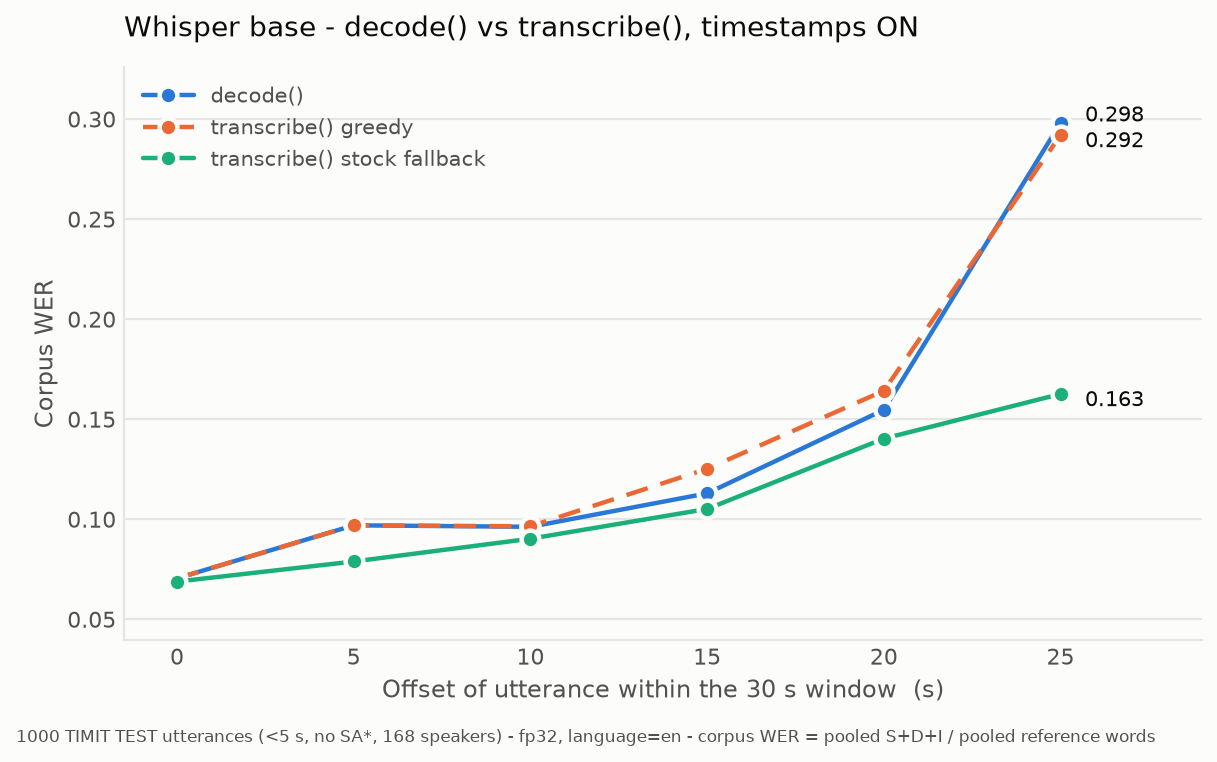

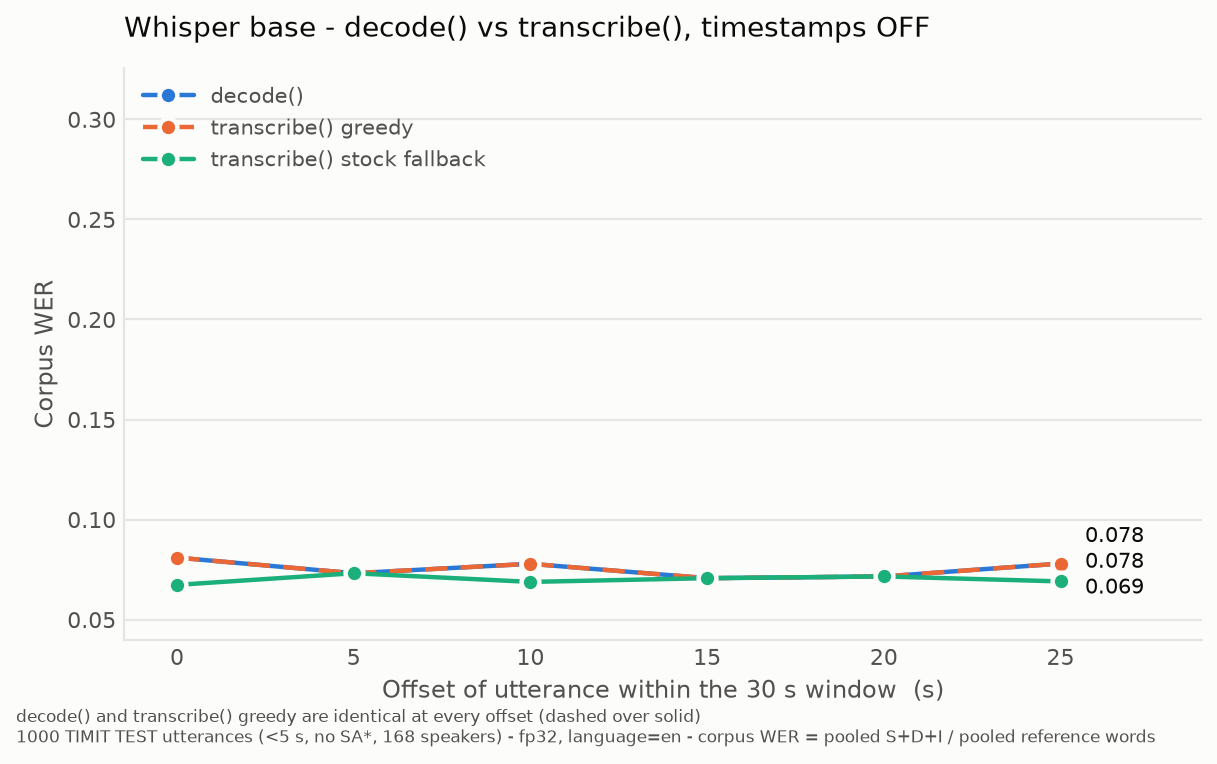

In [7]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e5e2"
SERIES = {"decode": "#2a78d6", "greedy": "#eb6834", "stock": "#1baf7a"}
LABEL  = {"decode": "decode()", "greedy": "transcribe() greedy",
          "stock": "transcribe() stock fallback"}
# greedy is drawn dashed on top of decode() so that an EXACT overlap stays visible
# as dashes over a solid line, rather than looking like a missing series
STYLE  = {"decode": "-", "greedy": (0, (5, 3)), "stock": "-"}

_all = [summary[(k, ts, s)].wer for k in SERIES for ts in ("on", "off") for s in OFFSETS_S]
pad = max((max(_all) - min(_all)) * 0.12, 0.004)
YLIM = (min(_all) - pad, max(_all) + pad)


def plot_arm(ts, fname):
    fig, ax = plt.subplots(figsize=(7.6, 4.6), dpi=160)
    fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
    ax.grid(True, axis="y", color=GRID, linewidth=1, linestyle="-")
    ax.set_axisbelow(True)

    ends = []
    for z, key in enumerate(("decode", "greedy", "stock")):
        wers = [summary[(key, ts, s)].wer for s in OFFSETS_S]
        ax.plot(OFFSETS_S, wers, color=SERIES[key], linewidth=2, linestyle=STYLE[key],
                marker="o", markersize=8, markeredgecolor=SURFACE, markeredgewidth=2,
                label=LABEL[key], solid_capstyle="round", solid_joinstyle="round", zorder=3 + z)
        ends.append([wers[-1], SERIES[key]])

    # stagger the end labels so near-identical values do not overprint
    span = YLIM[1] - YLIM[0]
    ends.sort(key=lambda e: e[0])
    for i in range(1, len(ends)):
        if ends[i][0] - ends[i - 1][0] < span * 0.045:
            ends[i][0] = ends[i - 1][0] + span * 0.045
    for (ypos, colour), key in zip(ends, sorted(("decode", "greedy", "stock"),
                                                key=lambda k: summary[(k, ts, OFFSETS_S[-1])].wer)):
        ax.annotate(f"{summary[(key, ts, OFFSETS_S[-1])].wer:.3f}", (OFFSETS_S[-1], ypos),
                    textcoords="offset points", xytext=(11, -3), fontsize=9.5,
                    color=INK, va="center", annotation_clip=False)

    ax.set_ylim(*YLIM)
    ax.set_xticks(OFFSETS_S)
    ax.set_xlim(-1.5, 29)
    ax.set_xlabel("Offset of utterance within the 30 s window  (s)", fontsize=11, color=INK2)
    ax.set_ylabel("Corpus WER", fontsize=11, color=INK2)
    ax.set_title(f"Whisper base - decode() vs transcribe(), timestamps {ts.upper()}",
                 fontsize=12.5, color=INK, pad=14, loc="left")
    ax.tick_params(colors=INK2, labelsize=10, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID); ax.spines[side].set_linewidth(1)
    leg = ax.legend(frameon=False, fontsize=9.5, loc="upper left", handlelength=2.4)
    for t in leg.get_texts():
        t.set_color(INK2)

    # say so explicitly wherever two curves are identical everywhere
    same = all(abs(summary[("decode", ts, s)].wer - summary[("greedy", ts, s)].wer) < 1e-9
               for s in OFFSETS_S)
    note = ("decode() and transcribe() greedy are identical at every offset "
            "(dashed over solid)\n") if same else ""

    fig.text(0.005, -0.02,
             note + "1000 TIMIT TEST utterances (<5 s, no SA*, 168 speakers) - fp32, "
             "language=en - corpus WER = pooled S+D+I / pooled reference words",
             fontsize=7.5, color=INK2)
    fig.tight_layout()
    fig.savefig(fname, bbox_inches="tight", facecolor=SURFACE)
    print(f"wrote {fname}")


for ts, fn in (("on", "transcribe_wer_vs_offset_timestamps_on.png"),
               ("off", "transcribe_wer_vs_offset_timestamps_off.png")):
    plot_arm(ts, fn)
plt.show()

## 8. Verification

In [8]:
ok = []

assert len(FILES) == 1000 and len({r["speaker"] for r in FILES}) == 168
assert {r["path"] for r in FILES} == {r["path"] for r in json.load(
    open(os.path.join(CORPUS_DIR, "corpus_manifest.json")))["files"]}
ok.append("1. corpus: the same 1000 frozen clips, all digests verified at load")

assert MAN["results_csv_sha256"] == sha256_file(DECODE_CSV)
ok.append("2. baseline: offset_results.csv matches the digest corpus_frozen/ was frozen against")

assert len(rows) == len(FILES) * len(OFFSETS_S) * len(TS_ARMS) * len(FB_ARMS) == 24000
assert len({(r["path"], r["offset_s"], r["timestamps"], r["fallback"]) for r in rows}) == 24000
ok.append("3. grid: 24000 rows, no duplicates, no gaps")

# the greedy arm must never have escalated temperature; the stock arm is allowed to
assert all(float(r["max_temp"]) == 0.0 for r in rows if r["fallback"] == "greedy")
ok.append("4. greedy arm: temperature never escalated above 0 (fallback ladder truly inert)")

# reproducibility of the stochastic arm: re-run a few stock cells against their stored seed
_probe = [r for r in rows if r["fallback"] == "stock" and int(r["offset_s"]) == 25
          and r["timestamps"] == "on"][:8]
for r in _probe:
    torch.manual_seed(seed_for(r["path"], 25, True, "stock"))
    res = model.transcribe(place(AUDIO[r["path"]], 25 * SAMPLE_RATE),
                           temperature=FB_ARMS["stock"], without_timestamps=False, **BASE)
    assert res["text"].strip() == r["text"], r["path"]
ok.append(f"5. determinism: {len(_probe)} stock-arm cells reproduce exactly under their stored seed")

for fn in ("transcribe_wer_vs_offset_timestamps_on.png",
           "transcribe_wer_vs_offset_timestamps_off.png"):
    assert os.path.getsize(fn) > 10000, fn
ok.append("6. figures: both PNGs written")

for line in ok:
    print("PASS  " + line)

PASS  1. corpus: the same 1000 frozen clips, all digests verified at load
PASS  2. baseline: offset_results.csv matches the digest corpus_frozen/ was frozen against
PASS  3. grid: 24000 rows, no duplicates, no gaps
PASS  4. greedy arm: temperature never escalated above 0 (fallback ladder truly inert)
PASS  5. determinism: 8 stock-arm cells reproduce exactly under their stored seed
PASS  6. figures: both PNGs written
